In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

path = "data/"
listings_clean = pd.read_csv(path + "listings_clean.csv")

# EDA

In [49]:
print(listings_clean[['price', 'accommodates', 'review_scores_rating', "minimum_nights"]].describe())

print('\nroom_type counts:')
print(listings_clean['room_type'].value_counts())

print('\nproperty_type counts (top 10):')
print(listings_clean['property_type'].value_counts().head(10))

print()
print(f'minimum_nights > 365: {(listings_clean["minimum_nights"] > 365).sum()}')
print(f'minimum_nights > 100: {(listings_clean["minimum_nights"] > 100).sum()}')
print(f'minimum_nights > 30: {(listings_clean["minimum_nights"] > 30).sum()}')
print(f'minimum_nights <= 30: {(listings_clean["minimum_nights"] <= 30).sum()}')


           price  accommodates  review_scores_rating  minimum_nights
count 36613.0000    36613.0000            36613.0000      36613.0000
mean    197.6227        2.7695                4.7704         29.2343
std     356.2521        1.9145                0.3682         35.6643
min       8.0000        1.0000                1.0000          1.0000
25%      85.0000        2.0000                4.7500         30.0000
50%     150.0000        2.0000                4.8600         30.0000
75%     203.0000        4.0000                4.9400         30.0000
max   20000.0000       16.0000                5.0000       1250.0000

room_type counts:
room_type
Entire home/apt    19706
Private room       16237
Hotel room           491
Shared room          179
Name: count, dtype: int64

property_type counts (top 10):
property_type
Entire rental unit             15568
Private room in rental unit     9951
Private room in home            2532
Room in hotel                   1429
Entire home                   

In [34]:
# log transform price
listings_clean['price_log'] = np.log1p(listings_clean['price'])

# create has_reviews flag BEFORE imputing
listings_clean['has_reviews'] = (listings_clean['review_scores_rating'] > 0).astype(int)

# impute missing review scores with median from reviewed listings only
median_score = listings_clean[listings_clean['has_reviews'] == 1]['review_scores_rating'].median()
listings_clean.loc[listings_clean['has_reviews'] == 0, 'review_scores_rating'] = median_score

In [40]:
# final EDA checklist
print('NULL CHECK:')
print(listings_clean[['price', 'price_log', 'review_scores_rating',
                       'has_reviews', 'room_type',
                       'neighbourhood_group_cleansed',
                       'accommodates']].isnull().sum())

print('\n DISTRIBUTIONS: ')
print(listings_clean[['price', 'price_log', 
                       'review_scores_rating', 
                       'accommodates']].describe())

print('\n CATEGORICAL COUNTS: ')
print(listings_clean['room_type'].value_counts())
print(listings_clean['neighbourhood_group_cleansed'].value_counts())

print('\n HAS REVIEWS: ')
print(listings_clean['has_reviews'].value_counts())
print(f'Imputed check: {listings_clean[listings_clean["has_reviews"] == 0]["review_scores_rating"].unique()}')

print('\n TOTAL LISTINGS: ')
print(f'Total: {len(listings_clean)}')

NULL CHECK:
price                           0
price_log                       0
review_scores_rating            0
has_reviews                     0
room_type                       0
neighbourhood_group_cleansed    0
accommodates                    0
dtype: int64

 DISTRIBUTIONS: 
           price  price_log  review_scores_rating  accommodates
count 36613.0000 36613.0000            36613.0000    36613.0000
mean    197.6227     4.9955                4.7704        2.7695
std     356.2521     0.6832                0.3682        1.9145
min       8.0000     2.1972                1.0000        1.0000
25%      85.0000     4.4543                4.7500        2.0000
50%     150.0000     5.0173                4.8600        2.0000
75%     203.0000     5.3181                4.9400        4.0000
max   20000.0000     9.9035                5.0000       16.0000

 CATEGORICAL COUNTS: 
room_type
Entire home/apt    19706
Private room       16237
Hotel room           491
Shared room          179
Name: coun

# Visualizations

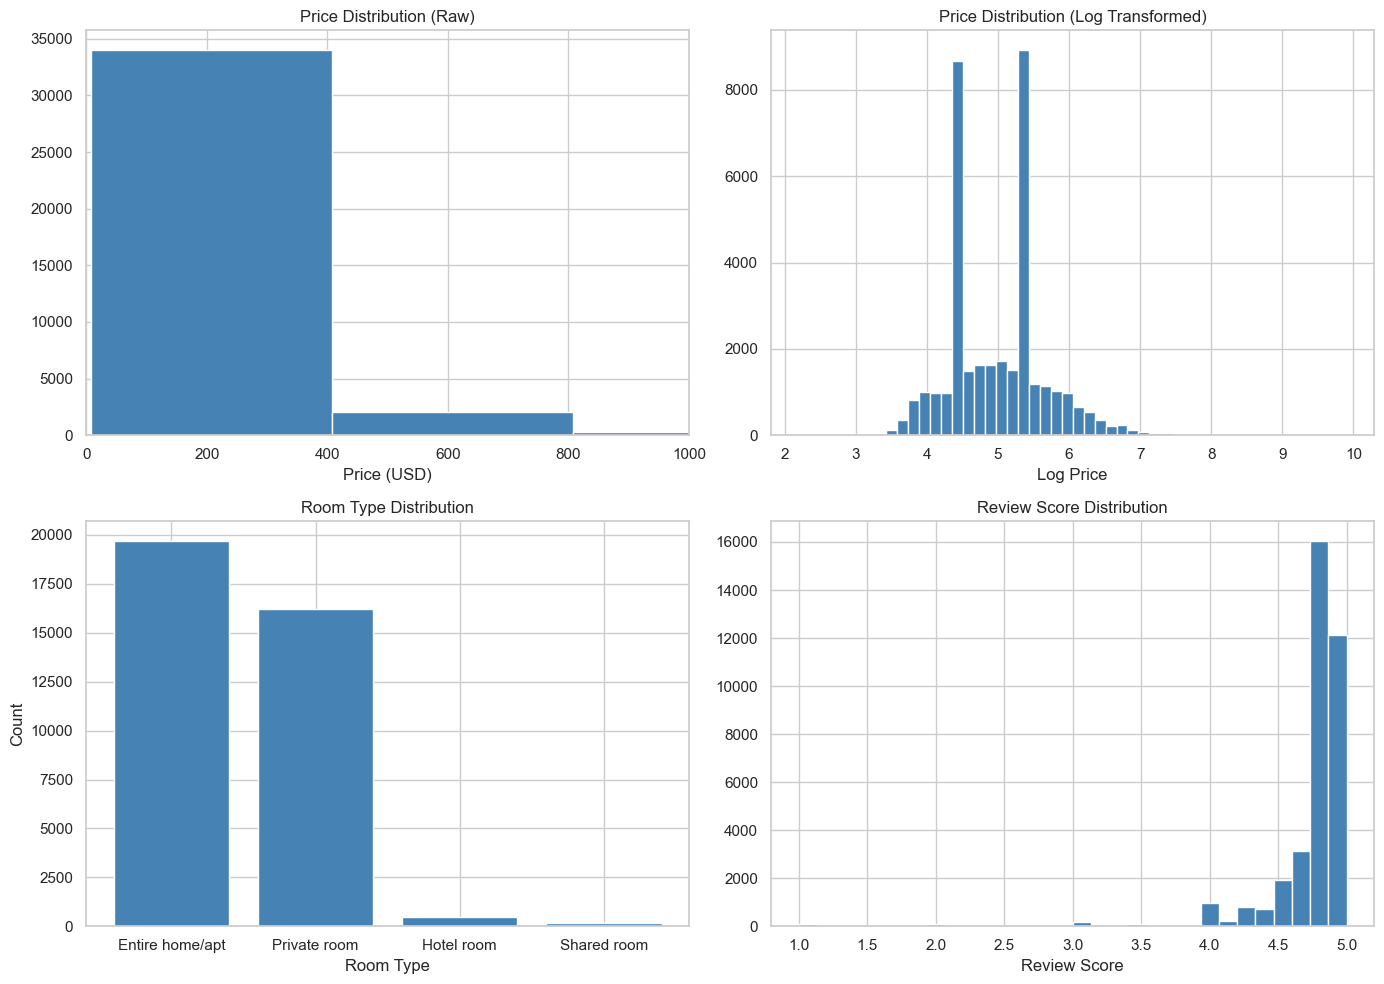

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# price raw -- zoomed in
axes[0, 0].hist(listings_clean['price'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Price Distribution (Raw)')
axes[0, 0].set_xlabel('Price (USD)')
axes[0, 0].set_xlim(0, 1000)

# price log transformed
axes[0, 1].hist(listings_clean['price_log'], bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Price Distribution (Log Transformed)')
axes[0, 1].set_xlabel('Log Price')

# room type counts
room_counts = listings_clean['room_type'].value_counts()
axes[1, 0].bar(room_counts.index, room_counts.values, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Room Type Distribution')
axes[1, 0].set_xlabel('Room Type')
axes[1, 0].set_ylabel('Count')

# review score distribution
axes[1, 1].hist(listings_clean['review_scores_rating'], bins=30, color='steelblue', edgecolor='white')
axes[1, 1].set_title('Review Score Distribution')
axes[1, 1].set_xlabel('Review Score')

plt.tight_layout()
plt.show()